In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data = pd.read_csv("placement (2).csv")

In [9]:
data.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [11]:
data.drop("Unnamed: 0", axis=1)

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


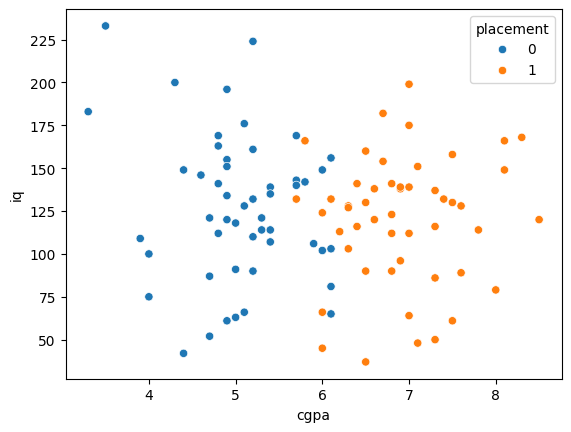

In [19]:
sns.scatterplot(data=data, x='cgpa', y='iq', hue='placement')
plt.show()

In [32]:
x = data.iloc[:, 0:2]
y = data.iloc[:, -1]

In [21]:
from sklearn.linear_model import Perceptron

In [36]:
pc = Perceptron(tol=1e-3, random_state = 42)

In [37]:
pc.fit(x,y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",42


In [38]:
pc.score(x,y)

0.5

In [39]:
pc.coef_

array([[-16. ,  10.1]])

In [40]:
pc.intercept_

array([-76.])

In [44]:
from mlxtend.plotting import plot_decision_regions

/home/hp/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


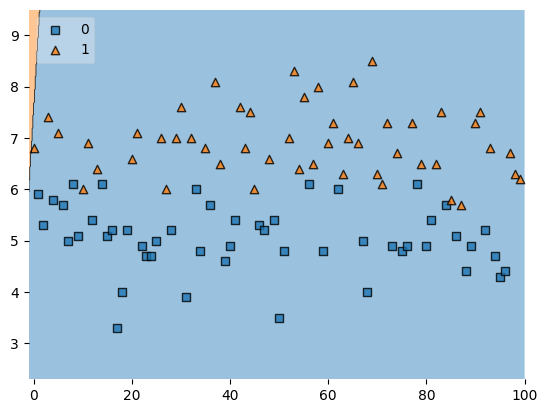

In [46]:
plot_decision_regions(x.values,y.values,clf =pc, legend = 2)
plt.show()

In [1]:
from sklearn.datasets import make_classification
import numpy as np

In [3]:
X, y = make_classification(n_samples = 100, n_features = 2, n_informative = 1, n_redundant = 0, n_classes = 2, 
                           n_clusters_per_class = 1,random_state = 41, hypercube = False, class_sep = 10)

In [4]:
import matplotlib.pyplot as plt

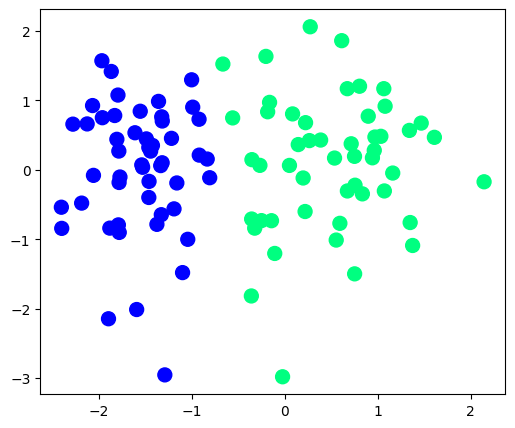

In [9]:
plt.figure(figsize = (6,5))
plt.scatter(X[:,0], X[:,1], c = y, cmap = 'winter', s = 100)
plt.show()

In [34]:
def perceptron (X, y):
    X = np.insert(X,0,1,axis = 1)
    weights  = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0, X.shape[0])
        y_hat = np.dot(X[j], weights)
        if y[j] * y_hat <= 0:
            weights = weights + lr*(y[j]-y_hat)*X[j]
            
    intercept_ = weights[0]
    coef_ = weights[1:]
    return intercept_, coef_

In [35]:
intercept_, coef_ = perceptron(X, y)

In [37]:
print(intercept_)
print(coef_)

0.13017372765498875
[0.09074927 0.00408516]


In [39]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [40]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input * b

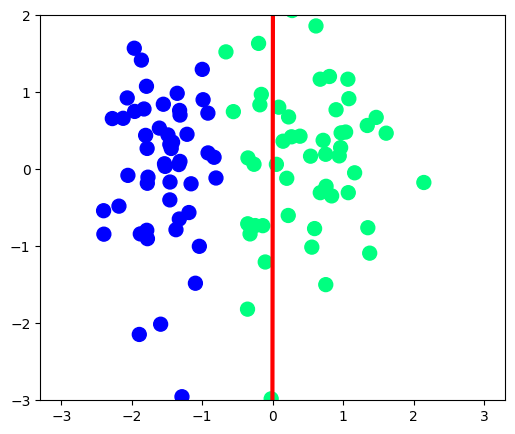

In [42]:
plt.figure(figsize = (6,5))
plt.plot(x_input, y_input, c = 'red', linewidth = 3)
plt.scatter(X[:,0], X[:,1], c = y, cmap = 'winter', s = 100)
plt.ylim(-3,2)
plt.show()